In [25]:
from pathlib import Path
import sys
import json
import numpy as np
import os 
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Covariance models: MEG vs iEEG

Compare **separate PCA**, **joint PCA on feature-concatenated modalities**, and **PLSSVD** using the same loaded data. All comparisons are descriptive and in sample. This notebook does not establish a statistically reliable or generalisable winner.

In [26]:
ROOT = Path.cwd()
if not (ROOT / 'coverage_matching_utils.py').exists() and (ROOT / 'iEEGvsMEG' / 'coverage_matching_utils.py').exists():
    ROOT = ROOT / 'iEEGvsMEG'
if not (ROOT / 'coverage_matching_utils.py').exists():
    raise FileNotFoundError('Set ROOT to the directory containing coverage_matching.ipynb and coverage_matching_utils.py.')
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
sys.path.insert(0, str(ROOT.parent / 'LB'))
from src.setting import GetInfo, PROJECT_PATH
from coverage_matching_utils import load_dataset, compute_variance
from cov_models_utils import (
    fit_cov_models, evaluate_cov_models, plot_model_timecourses,
    plot_model_covariances, compare_cov_models,
)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

In [27]:
MEG_KIND = 'full_concatenated'  # full_average, full_concatenated, coverage_average, paired_coverage, random_control
BLOCK_SCALING = 'none'         # 'equal_variance' rescales each whole modality to total variance 1 for all three models. 

## Participants and coordinates

In [28]:
MEG_DIR = ROOT / 'MEG' / 'dataMEG'
IEEG_DIR = ROOT / 'ieeg_shortWOBS_fs250'

meg_subj_list = sorted(file.removesuffix('_source.p') for file in os.listdir(MEG_DIR) if file.endswith('_source.p'))
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = sorted(file.removesuffix('_epochs.p') for file in os.listdir(IEEG_DIR) if file.endswith('_epochs.p'))
if not meg_subj_list or not ieeg_subj_list:
    raise FileNotFoundError('Check MEG_DIR and IEEG_DIR: no source or epoch files found.')
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = IEEG_DIR / f'{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time = d['time_epoch']

SFREQ = 250
CONDITIONS = (1, 2)    

CONDITION_MODE = 'average'  # Always average conditions before model fitting.
PAIRING = None  
N_COMPONENTS = 10

project_path = ROOT.parent / PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=str(IEEG_DIR), project_path=str(project_path))
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

MEG Subject number :  32
iEEG Subject number :  30


## Load the selected MEG setup and iEEG

In [29]:
electrode_metadata = pd.DataFrame(coord, columns=['x', 'y', 'z'])
electrode_metadata['subject'] = subj_list
electrode_metadata['channel'] = elect_list
electrode_metadata['region'] = regions_ieeg
electrode_metadata['channel_index'] = electrode_metadata.groupby('subject', sort=False).cumcount()

ieeg = load_dataset('ieeg', meg_dir=MEG_DIR, ieeg_dir=IEEG_DIR,
    meg_subjects=meg_subj_list, ieeg_subjects=ieeg_subj_list,
    electrode_metadata=electrode_metadata,
    meg_coordinate_unit='m', ieeg_coordinate_unit='m',
    meg_tmin=float(time[0]), sfreq=SFREQ, conditions=CONDITIONS,
    condition_mode=CONDITION_MODE,
)

meg = load_dataset(MEG_KIND, reference=ieeg, pairing=PAIRING)
display(pd.DataFrame({'iEEG': compute_variance(ieeg), MEG_KIND: compute_variance(meg)}).T)

,n_observations,n_features,total_variance,mean_feature_variance
iEEG,1025.0,2576.0,140.009109,0.054351
full_concatenated,1025.0,113888.0,64345.126190,0.564986


## Fit the three models

| Model | Objective | Time courses used in matching |
|---|---|---|
| Separate PCA | Maximise each modality's own variance | `X Wx` and `Y Wy` from independent fits |
| Joint PCA | Maximise variance of `[X Y]` | Separate contributions `X Wx` and `Y Wy`; their sum is the joint score |
| PLSSVD | Maximise cross-covariance with unit-norm weights | `X Wx` and `Y Wy` from SVD of `X.T @ Y` |

All matrices are centred across observations. 

The helper uses exact sample-space decompositions, avoiding a huge source × electrode cross-covariance matrix for full MEG concatenation. Joint PCA is compared using its separate modality contributions, never by correlating its common score with itself.

In [30]:
models = fit_cov_models(ieeg, meg, n_components=N_COMPONENTS, block_scaling=BLOCK_SCALING)

## Variance explained and shared cross-covariance

`evaluate_cov_models` reports, cumulatively for the first **k** components:

- **`ieeg_variance_explained` / `meg_variance_explained`:** `1 − reconstruction error / total centred signal variance`, with a separate denominator for each modality. Separate PCA and PLS reconstruct through their own weights. Joint PCA reconstructs each modality using the joint score and its corresponding weight block.
- **`shared_crosscov_fraction`:** the fraction of squared cross-covariance captured by the retained feature subspaces. It is `||Qx.T C Qy||² / ||C||²`, where `C = X.T Y/(n−1)` and Qx/Qy are orthonormal bases of the retained weight spaces. For PLSSVD this equals the retained squared singular values divided by all squared singular values.

The last measure is **cross-covariance energy, not a uniquely identified shared biological variance**. It must not be added to the two variance-explained fractions. It depends on preprocessing and can include shared stimulus timing and sampling noise.

Native score variances and paired cross-covariances are included as additional columns. These reproduce the decomposition used in `LB_Summary.ipynb`, with explicit centring and denominators.

Separate PCA is expected to maximise each modality’s reconstruction variance, and PLSSVD to maximise retained cross-covariance energy. Those advantages are consequences of their objectives, not independent evidence of a better model.

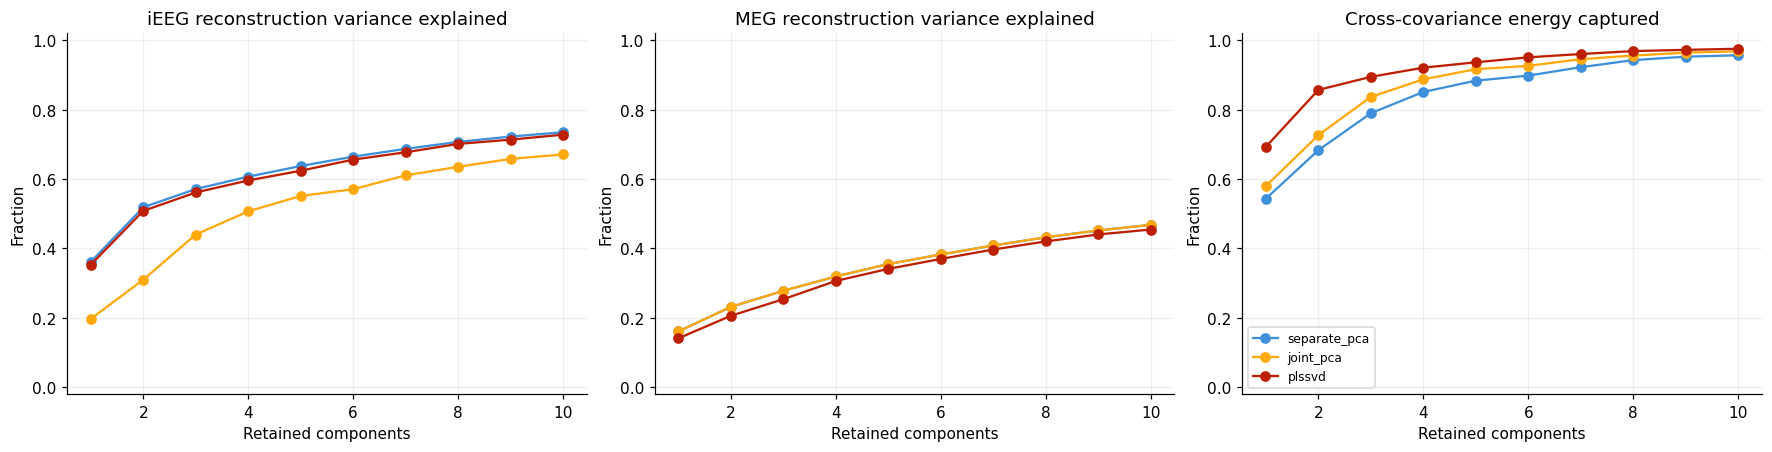

,model,ieeg_variance_explained,meg_variance_explained,shared_crosscov_fraction
2,separate_pca,0.571203,0.277902,0.789760
12,joint_pca,0.440209,0.277898,0.836773
22,plssvd,0.561391,0.253702,0.894661


In [31]:
variance = evaluate_cov_models(models)
display(variance.query('k == 3')[['model', 'ieeg_variance_explained',
    'meg_variance_explained', 'shared_crosscov_fraction']])

## Time courses

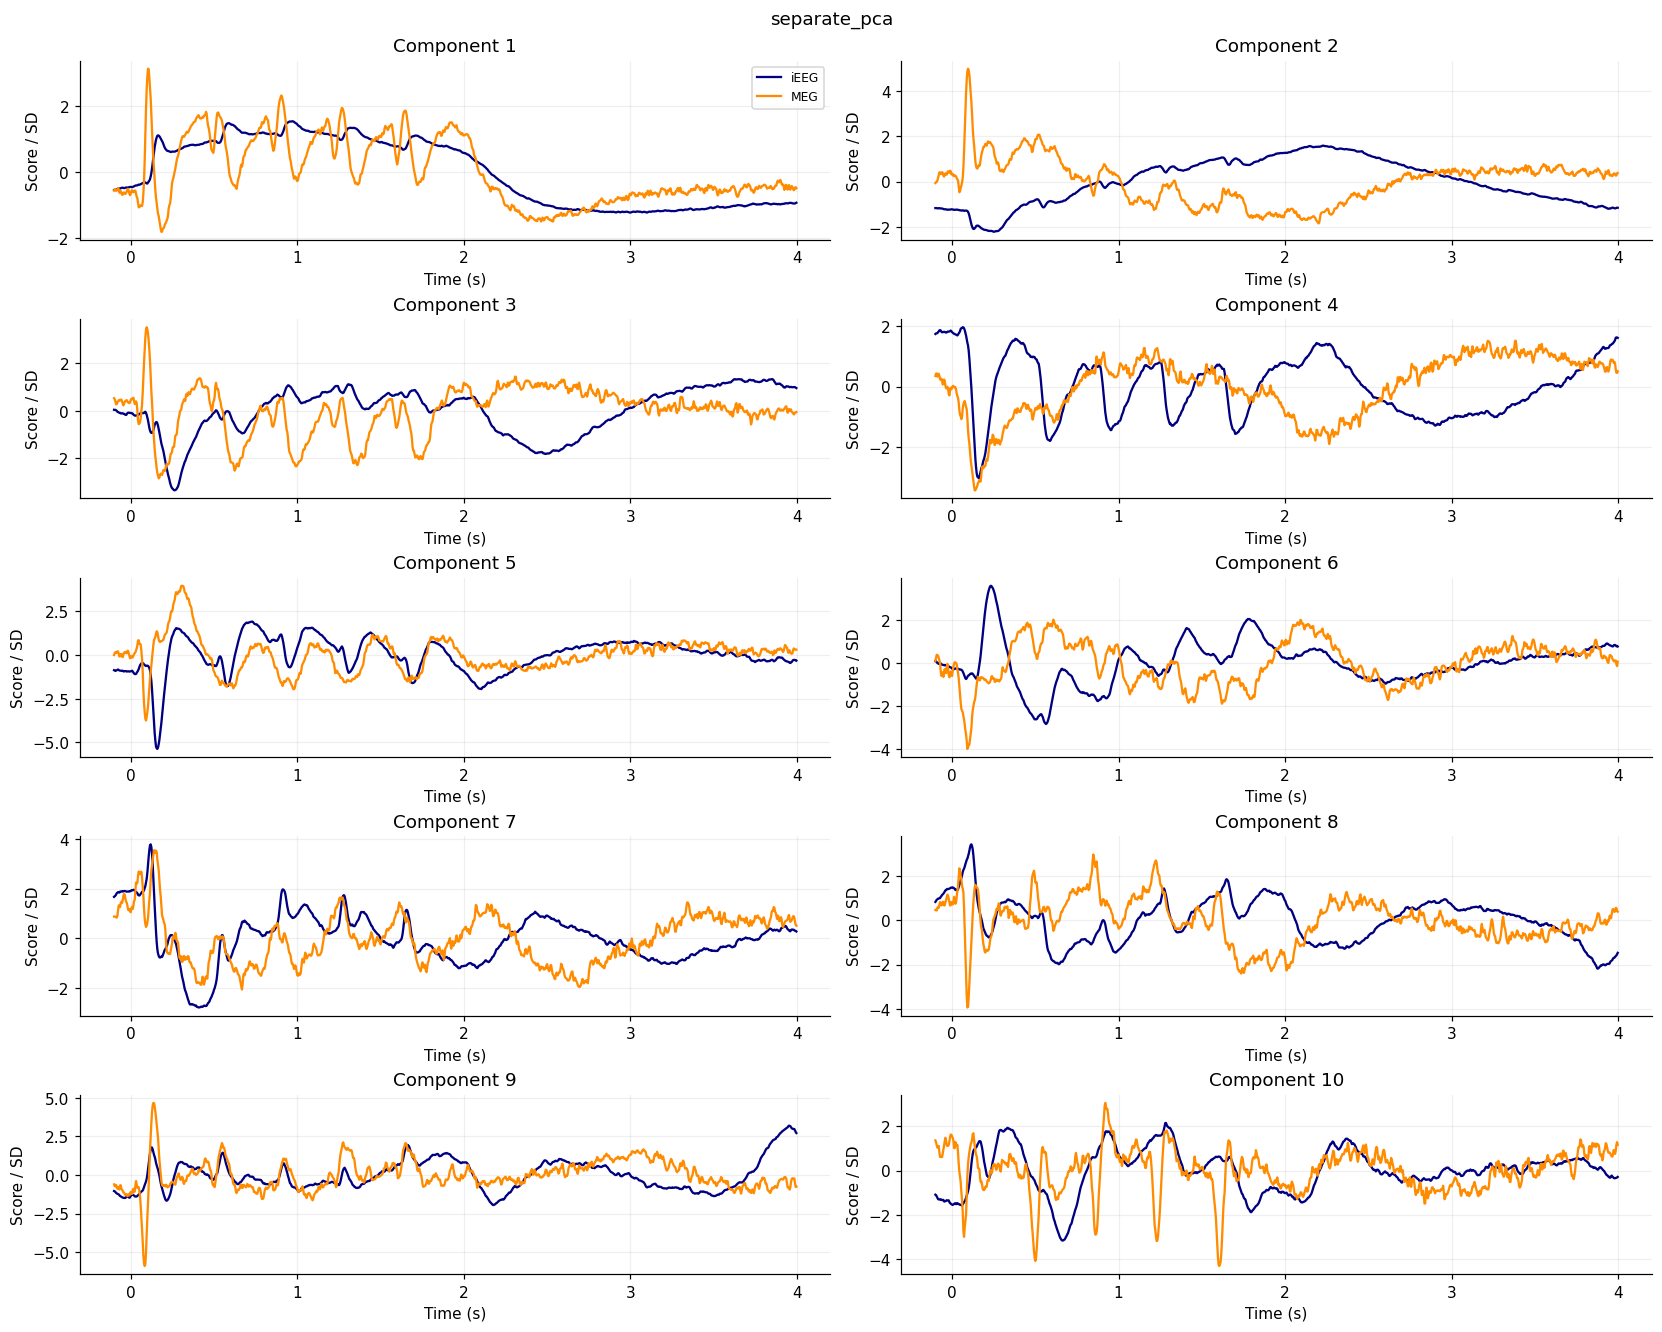

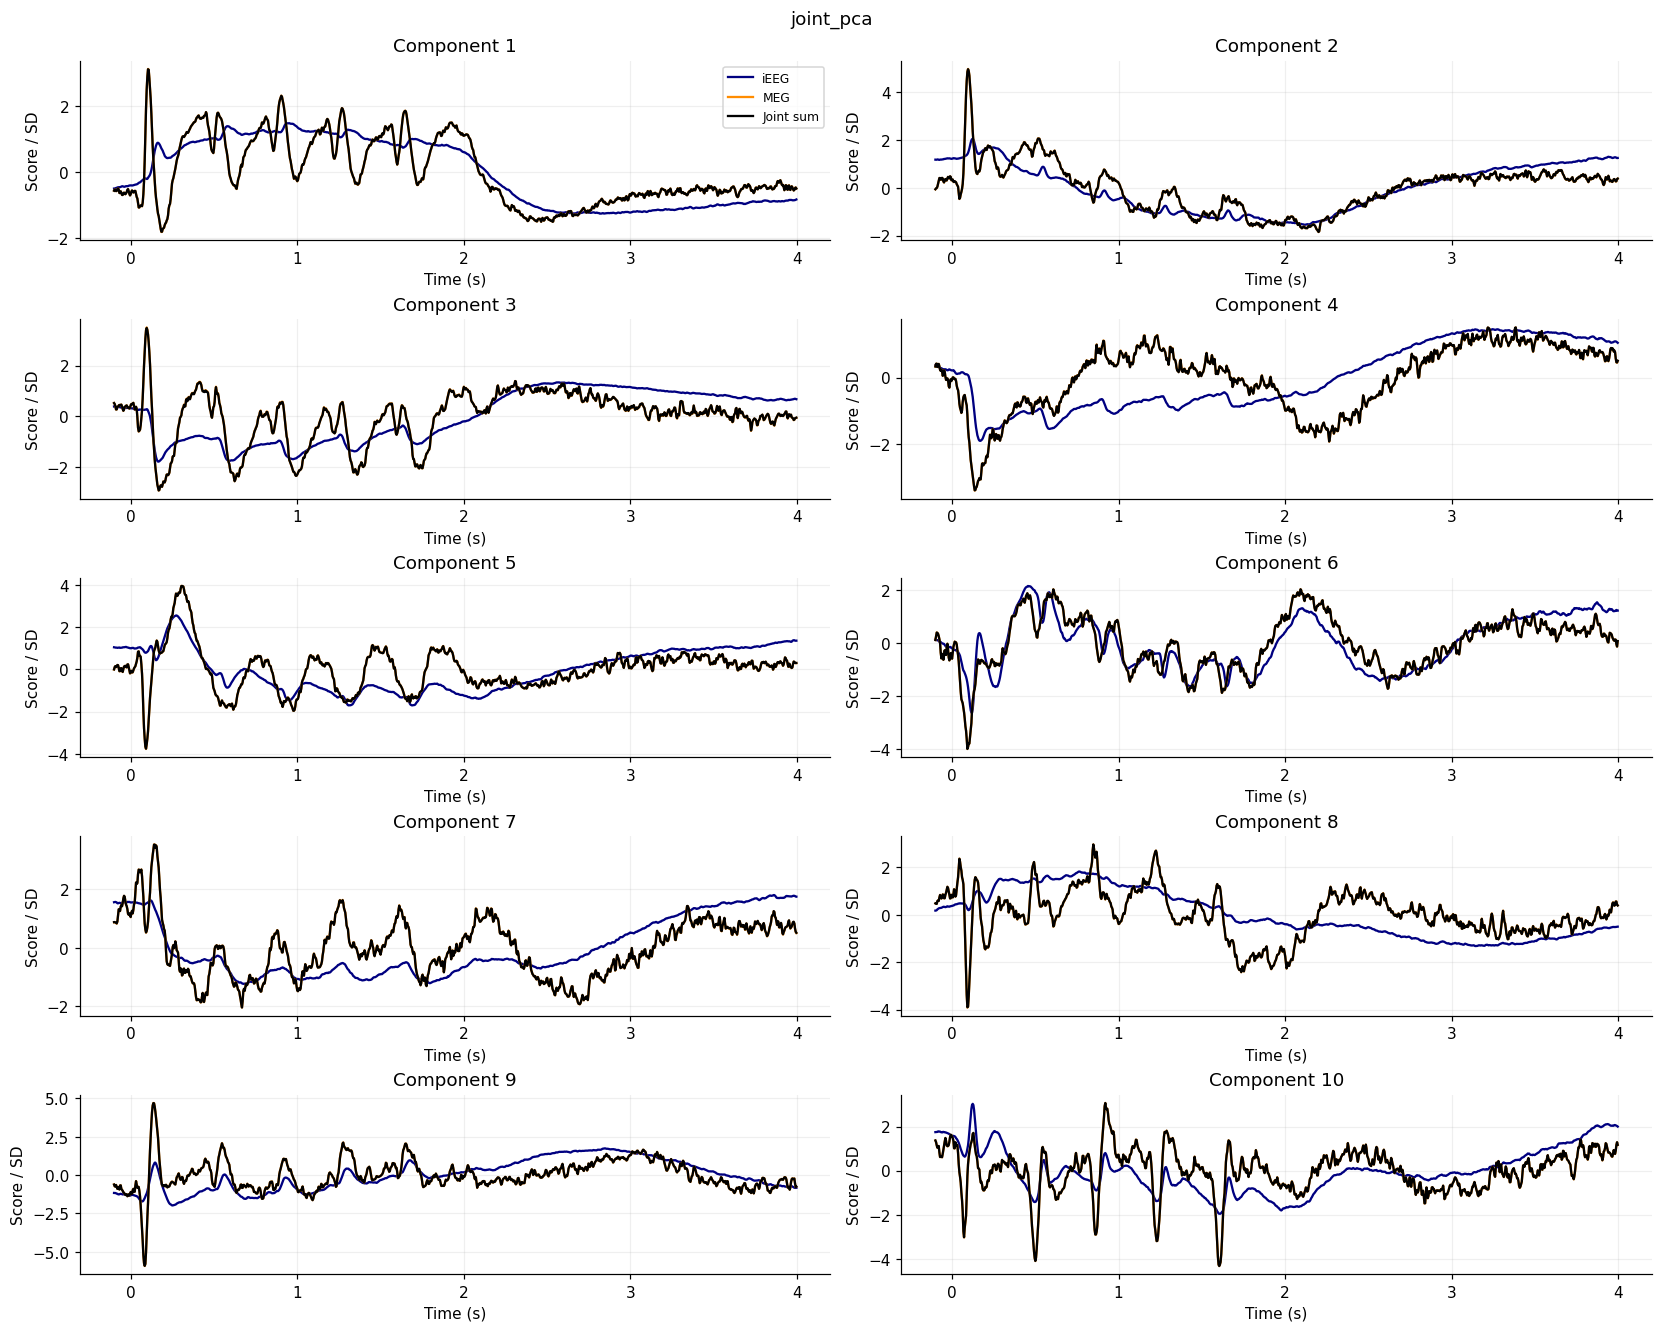

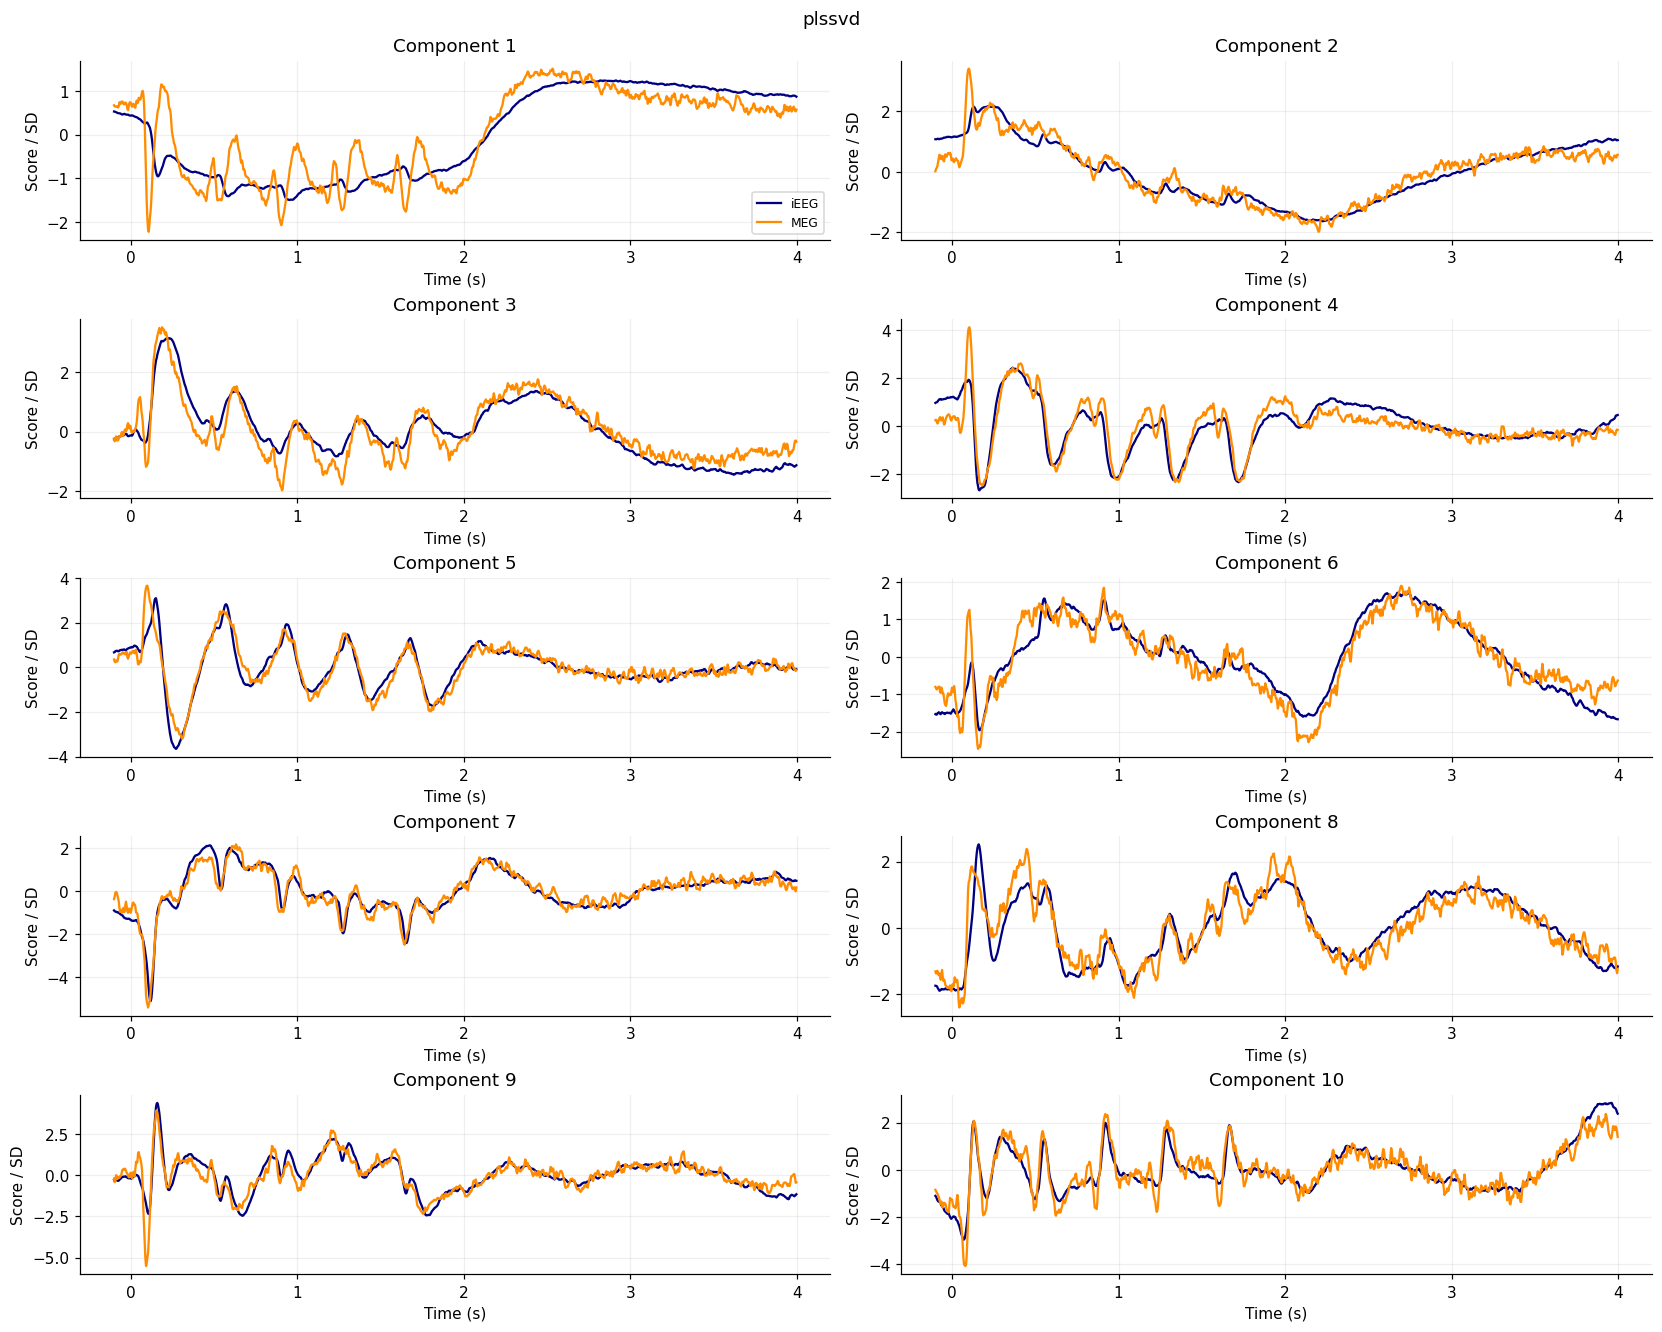

In [32]:
for model in models.values():
    plot_model_timecourses(model, n_components=N_COMPONENTS) #`standardize=False` to inspect native amplitudes TODO and add 2 axis implment a flip 

## Covariance structure
- Covariances
- Curves show `Var(iEEG score)`, `Var(MEG score)`, `2 Cov`, and their sum. Only for joint PCA is this sum the variance of the fitted joint PCA score. 

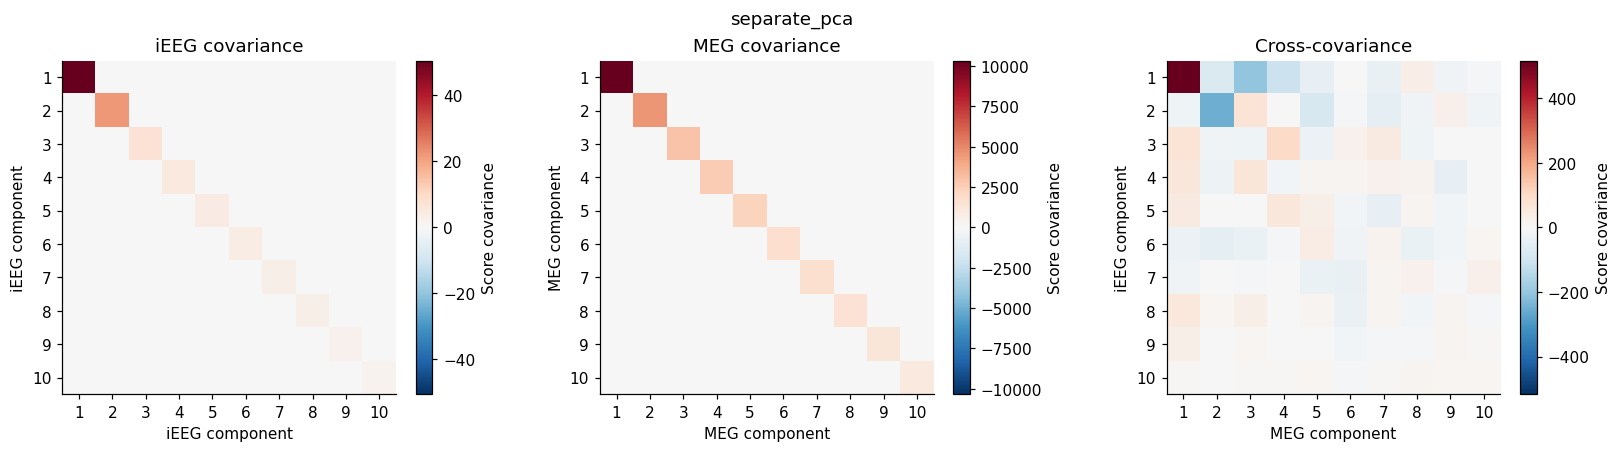

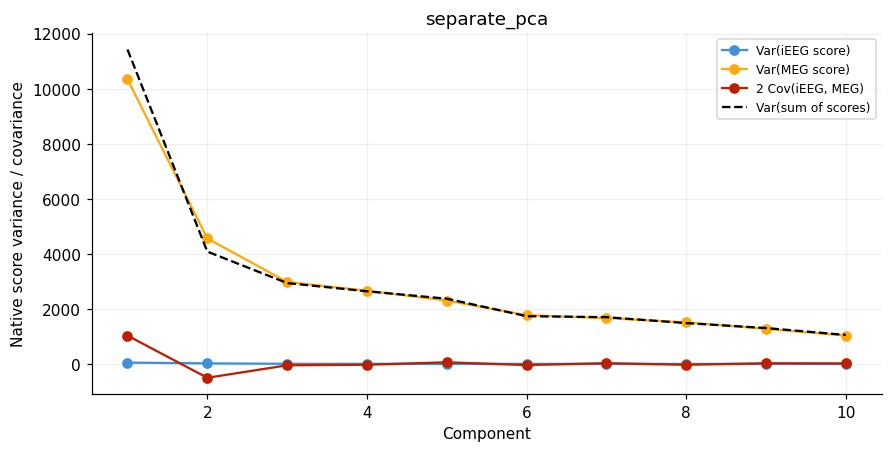

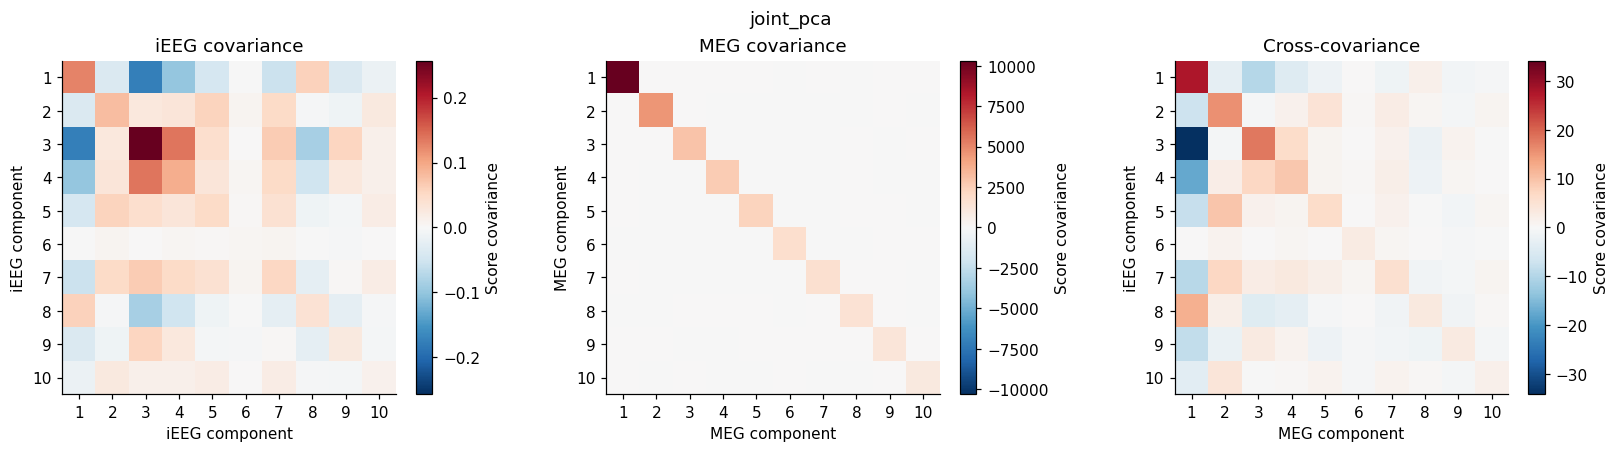

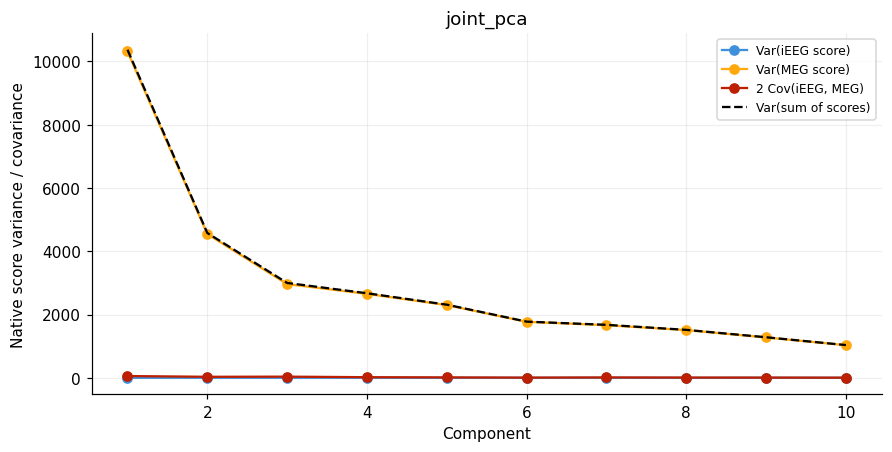

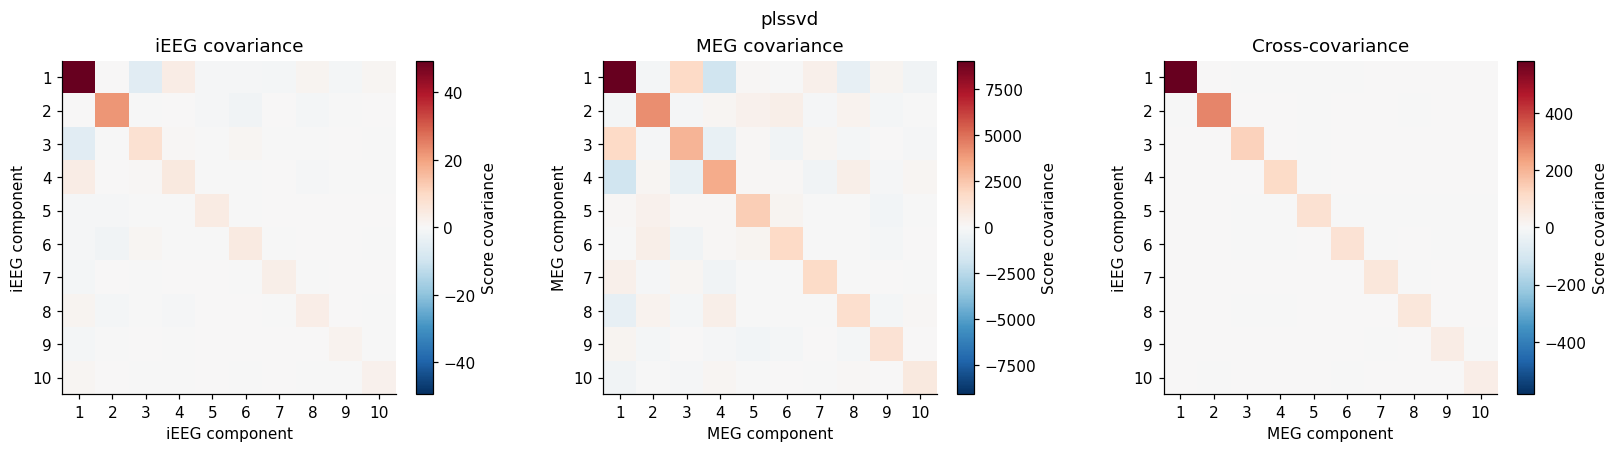

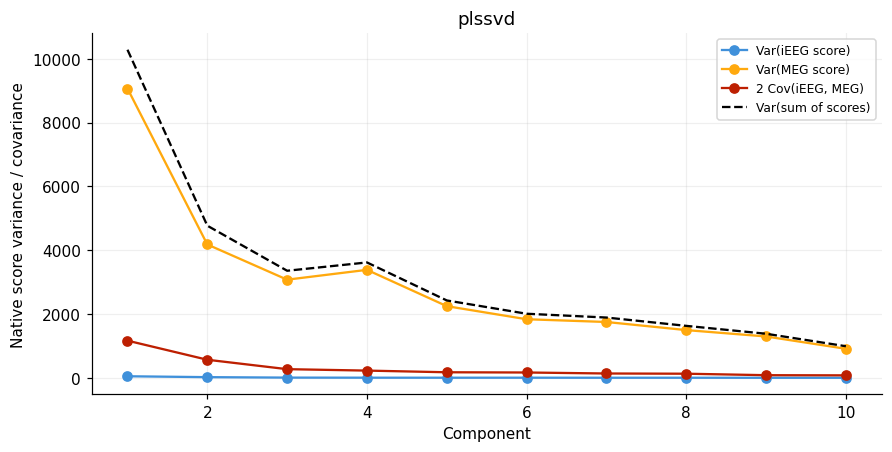

In [33]:
for model in models.values():
    plot_model_covariances(model, n_components=N_COMPONENTS) # scale=True 

## Which model gives the closest components?

Two complementary comparisons, always at the same number of retained components:

1. **Native cross-modal matching:** `native_matched_abs_r` pairs iEEG and MEG components within each model to maximise mean absolute Pearson correlation. `native_paired_abs_r` keeps the model's own component pairs. `rank_native_matching` ranks the first measure.
2. **Fixed iEEG-PCA reference:** use each model's **MEG-only** scores to reproduce the same independent iEEG PCA time courses. `ieeg_variance_captured`, `subspace_overlap`, and `matched_abs_r` are exactly the metrics from the coverage notebook. `rank_ieeg_reference` ranks variance captured from the retained reference PCs. This fraction is different from reconstruction variance explained in all original iEEG channels.

A model can achieve high native matching by concentrating on a small common signal and leaving much of either dataset unexplained. Read matching alongside reconstruction variance and shared cross-covariance capture. 

In [34]:
# TODO change to Spearman for the native matched abs r
# 

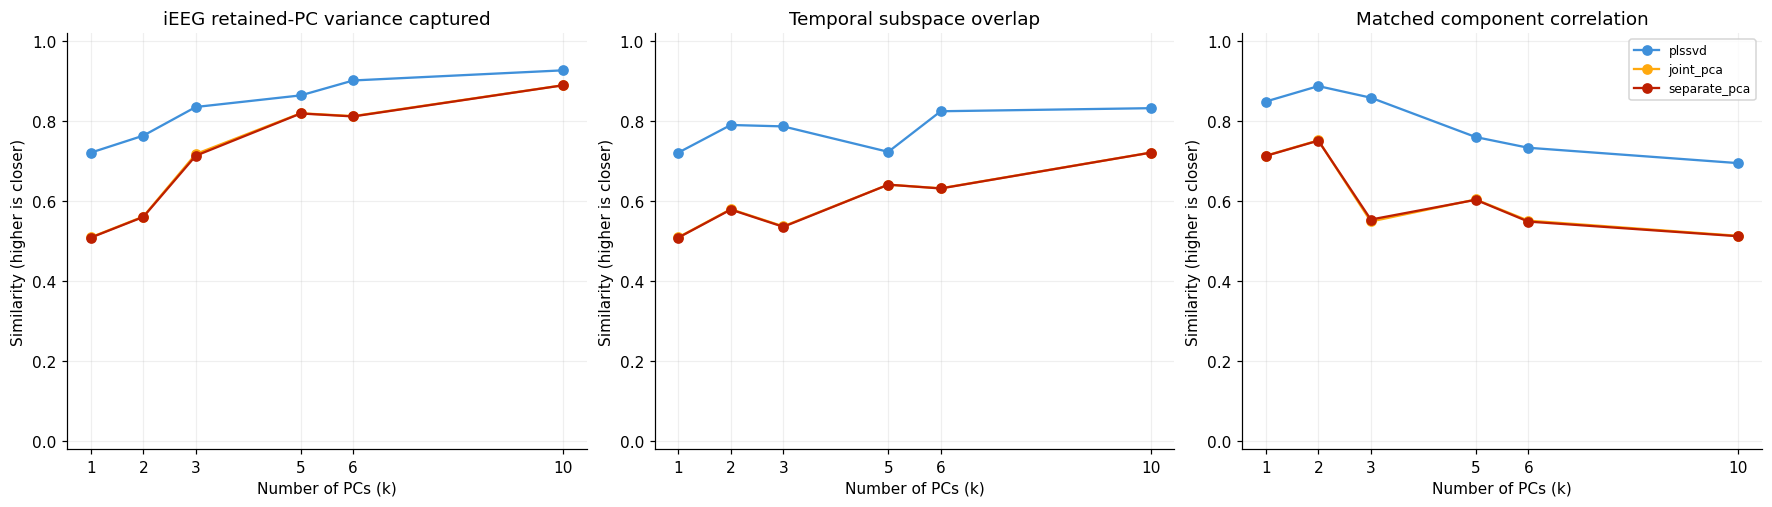

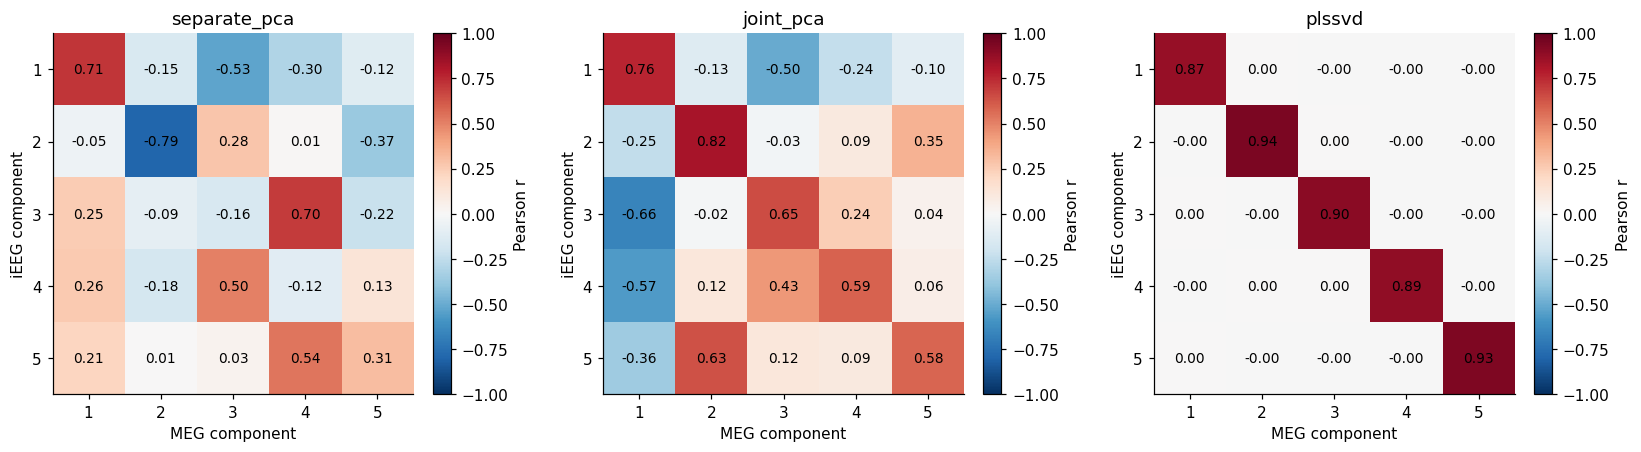

,model,native_paired_abs_r,native_matched_abs_r,rank_native_matching,ieeg_variance_explained,meg_variance_explained,shared_crosscov_fraction
12,plssvd,0.908730,0.908730,1,0.656075,0.369772,0.950853
13,joint_pca,0.708958,0.708958,2,0.570687,0.382648,0.926351
14,separate_pca,0.388608,0.549231,3,0.664600,0.382649,0.898149


,model,ieeg_variance_captured,subspace_overlap,matched_abs_r,rank_ieeg_reference
12,plssvd,0.902127,0.825140,0.733857,1
13,joint_pca,0.812927,0.632471,0.551530,2
14,separate_pca,0.812165,0.632035,0.549231,3


,model,k,ieeg_component,meg_component,signed_r,abs_r
33,plssvd,6,1,1,0.870477,0.870477
34,plssvd,6,2,2,0.941453,0.941453
35,plssvd,6,3,3,0.899736,0.899736
36,plssvd,6,4,4,0.886186,0.886186
37,plssvd,6,5,5,0.931438,0.931438
38,plssvd,6,6,6,0.923089,0.923089
39,joint_pca,6,1,1,0.758207,0.758207
40,joint_pca,6,2,2,0.823729,0.823729
41,joint_pca,6,3,3,0.651908,0.651908
42,joint_pca,6,4,4,0.590985,0.590985


In [35]:
comparison, component_pairs, reference_pairs = compare_cov_models(
    models, n_components=(1, 2, 3, 5,6, 10),
)
display(comparison.query('k == 6').sort_values('rank_native_matching')[
    ['model', 'native_paired_abs_r', 'native_matched_abs_r', 'rank_native_matching',
     'ieeg_variance_explained', 'meg_variance_explained', 'shared_crosscov_fraction']])
display(comparison.query('k == 6').sort_values('rank_ieeg_reference')[
    ['model', 'ieeg_variance_captured', 'subspace_overlap', 'matched_abs_r', 'rank_ieeg_reference']])
display(component_pairs.query('k == 6'))

## Within-modality model similarity
**Subspace overlap** compares all retained patterns together and permits rotations/mixing of their axes. **Mean matched |r|** compares individual component pairs and averages their absolute Pearson correlations.

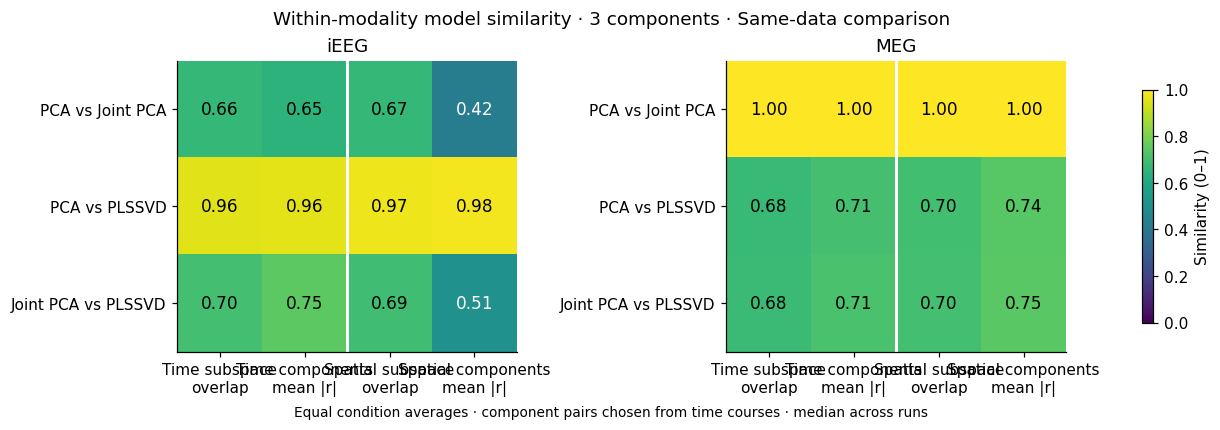

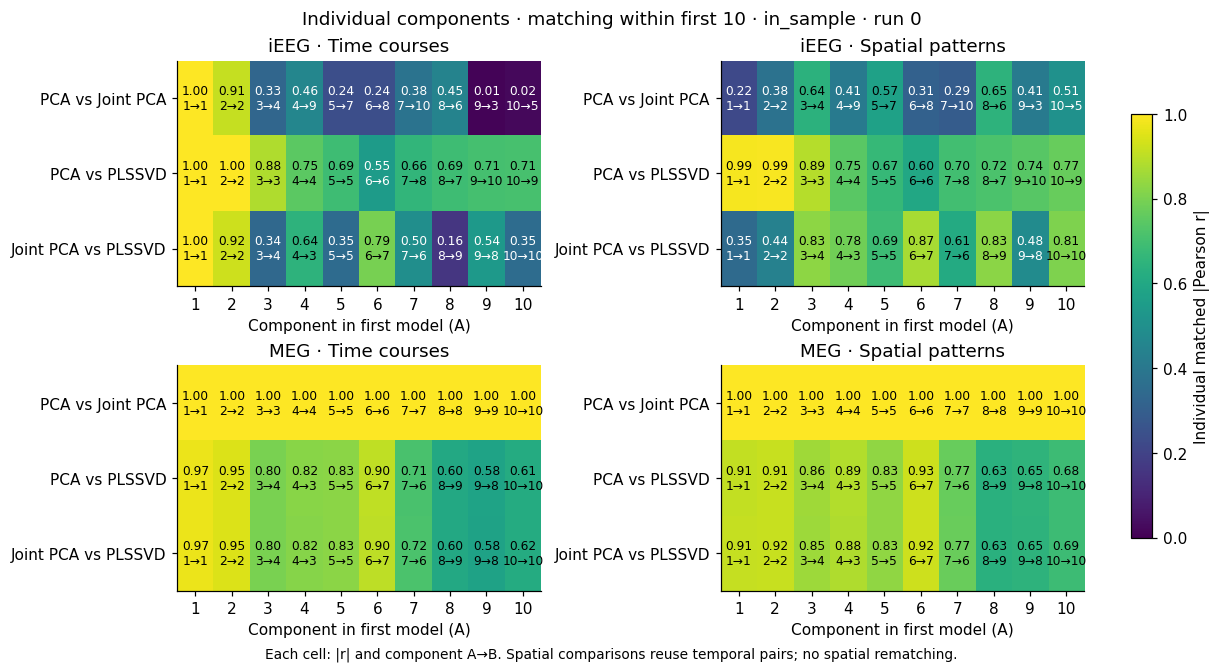

In [36]:
from compare_models import compare_cov_models_within, plot_within_models, plot_within_components

COMPONENT_K = min(10, min(min(m.ieeg_scores.shape[1], m.meg_scores.shape[1]) for m in models.values()))
within_models = compare_cov_models_within(
    models, ieeg, meg, dimensions=range(1, COMPONENT_K + 1),
)
# All detailed metrics, assignments and correlations are saved below.
# Display one compact summary for the selected dimension.
WITHIN_K = min(3, COMPONENT_K)
WITHIN_OUTPUT = ROOT / 'out' / 'cov_models_within'
WITHIN_OUTPUT.mkdir(parents=True, exist_ok=True)
for name, table in within_models.items():
    table.to_csv(WITHIN_OUTPUT / f'{name}.csv', index=False)
for fig in plot_within_models(within_models, k=WITHIN_K, partition='in_sample'):
    fig.savefig(WITHIN_OUTPUT / f'within_models_k{WITHIN_K}.png', dpi=200, bbox_inches='tight')
    fig.savefig(WITHIN_OUTPUT / f'within_models_k{WITHIN_K}.pdf', bbox_inches='tight')
    display(fig)
    plt.close(fig)

# One fixed assignment among the first up-to-10 components, not cumulative k curves.
fig = plot_within_components(within_models, k=COMPONENT_K, partition="in_sample")
for extension in ("png", "pdf"):
    fig.savefig(WITHIN_OUTPUT / f"within_individual_components_k{COMPONENT_K}.{extension}", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)
